# Music Generation Evaluation

This notebook implements a complete, reproducible MIDI evaluation pipeline for the LSTM baseline and the RAG-based music generation system.

- `RAG Leakage Rate`: 4-gram overlap between generated and retrieved prompt material. Implemented in the core module as an optional metric when retrieval references are available.
- `Pitch Entropy`: Shannon entropy over pitch-class usage.
- `Scale Consistency`: ratio of notes explainable by the best-fitting major or minor scale.
- `Note Density`: notes per second.
- `Empty Beat Rate`: fraction of beat intervals without active notes.
- `Structural Consistency`: average self-similarity between bar-level pitch-class histograms.
- `Pitch Diversity`: unique MIDI pitches divided by note count.
- `Repetition Rate`: repeated 4-gram pitch-duration patterns divided by all 4-grams.
- `Rhythm Consistency`: cosine similarity between adjacent bar-level onset histograms.
- `Length Statistics`: note count, duration, and note-duration moments.

In [71]:
from pathlib import Path
import sys
import subprocess

ROOT = Path.cwd()

def ensure_packages() -> None:
    required = ['numpy', 'matplotlib', 'pretty_midi', 'scipy']
    missing = []
    for name in required:
        try:
            __import__(name)
        except ImportError:
            missing.append(name)
    if missing:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])

ensure_packages()
print(f'Notebook root: {ROOT}')

Notebook root: d:\study\SemB\CS5491_AI\Proj\MusicGen


In [72]:
"""
Symbolic MIDI evaluation for music generation (LSTM baseline vs. RAG).
符号化 MIDI 音乐生成评估（LSTM 基线 vs. RAG）。

- Parses MIDI with `pretty_midi`, builds per-measure features, and computes project metrics.
  使用 pretty_midi 解析 MIDI，构建逐小节特征并计算项目指标。
- Inlined in `evaluate.ipynb`; runnable as: `python evaluation_core.py`.
  在 evaluate.ipynb 中内联；也可命令行运行：python evaluation_core.py
"""
from __future__ import annotations

import json
import math
import shutil
import csv
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib
import numpy as np
import pretty_midi
from scipy.stats import ttest_ind


import matplotlib.pyplot as plt  # After backend selection.

# Project paths
ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DEFAULT_OUTPUTS_ROOT = ROOT / "outputs"
DEFAULT_RESULTS_PATH = ROOT / "results.json"
DEFAULT_PLOT_PATH = ROOT / "evaluation_comparison.png"
DEFAULT_MOS_RESULTS_PATH = ROOT / "mos_results.json"
DEFAULT_MOS_PLOT_PATH = ROOT / "mos_comparison.png"

# Time-grid constants 
BEATS_PER_BAR = 4  # Assume 4/4 meter for measure length.
RHYTHM_BINS_PER_BAR = 16  # Bins per bar for onset histograms (rhythm consistency).
NGRAM_SIZE = 4  # Pitch+duration 4-grams for repetition / leakage. 
MOTIF_SIZE = 4  # Notes per sliding motif window. 

# Pitch-class sets (C as 0) for major / natural minor scales.
MAJOR_SCALE = {0, 2, 4, 5, 7, 9, 11}
MINOR_SCALE = {0, 2, 3, 5, 7, 8, 10}


@dataclass
class NoteEvent:
    """One MIDI note | 单条音符事件。"""

    pitch: int  # MIDI 0–127
    start: float
    end: float
    duration: float  # end - start (clamped)
    velocity: int
    pitch_class: int  # pitch % 12


@dataclass
class MidiFeatures:
    """Precomputed arrays for metrics"""

    path: Path
    notes: list[NoteEvent]
    pitches: list[int]
    pitch_classes: list[int]
    durations: list[float]
    start_times: list[float]
    inter_onset_intervals: list[float]
    beat_times: np.ndarray
    beat_duration: float
    total_duration: float
    total_beats: float
    measure_pitch_histograms: list[np.ndarray]  # 12-dim per bar, pitch-class counts
    measure_rhythm_histograms: list[np.ndarray]  # 16-bins per bar, onset mass


def discover_midi_files(directory: Path) -> list[Path]:
    """Return sorted *.mid / *.midi paths"""
    return sorted(
        path
        for pattern in ("*.mid", "*.midi")
        for path in directory.glob(pattern)
        if path.is_file()
    )


def ensure_demo_inputs(outputs_root: Path = DEFAULT_OUTPUTS_ROOT) -> dict[str, Any]:
    outputs_root.mkdir(parents=True, exist_ok=True)
    lstm_dir = outputs_root / "lstm"
    rag_dir = outputs_root / "rag"
    lstm_dir.mkdir(parents=True, exist_ok=True)
    rag_dir.mkdir(parents=True, exist_ok=True)

    provenance: dict[str, Any] = {"demo_mode": False, "copied_files": {"lstm": [], "rag": []}}

    return provenance


def parse_midi(path: Path) -> MidiFeatures:
    """
    Load MIDI, skip drums, sort notes, infer beats from file or estimated tempo.

    Fills per-measure pitch/rhythm histograms for structural and rhythm metrics.
    """
    midi = pretty_midi.PrettyMIDI(str(path))
    notes: list[NoteEvent] = []

    for instrument in midi.instruments:
        if instrument.is_drum:  # Drums excluded from pitch metrics
            continue
        for note in instrument.notes:
            duration = max(note.end - note.start, 1e-6)
            notes.append(
                NoteEvent(
                    pitch=int(note.pitch),
                    start=float(note.start),
                    end=float(note.end),
                    duration=float(duration),
                    velocity=int(note.velocity),
                    pitch_class=int(note.pitch % 12),
                )
            )

    notes.sort(key=lambda n: (n.start, n.pitch, n.end))

    if notes:
        total_duration = max(float(midi.get_end_time()), max(note.end for note in notes))
    else:
        total_duration = float(midi.get_end_time())

    beat_times = midi.get_beats()
    if len(beat_times) < 2:  # Fallback: uniform beats from tempo
        estimated_tempo = midi.estimate_tempo()
        beat_duration = 60.0 / estimated_tempo if estimated_tempo > 1e-6 else 0.5
        if total_duration <= 0:
            total_duration = beat_duration
        beat_times = np.arange(0.0, total_duration + beat_duration, beat_duration, dtype=float)
    else:
        beat_duration = float(np.median(np.diff(beat_times)))

    if total_duration <= 0:
        total_duration = float(beat_times[-1]) if len(beat_times) else beat_duration

    if len(beat_times) < 2:
        beat_times = np.array([0.0, total_duration], dtype=float)

    pitches = [note.pitch for note in notes]
    pitch_classes = [note.pitch_class for note in notes]
    durations = [note.duration for note in notes]
    start_times = [note.start for note in notes]
    inter_onset_intervals = np.diff(start_times).tolist() if len(start_times) >= 2 else []
    total_beats = max(total_duration / max(beat_duration, 1e-6), 1e-6)

    measure_pitch_histograms, measure_rhythm_histograms = build_measure_features(
        notes=notes,
        total_duration=total_duration,
        beat_duration=beat_duration,
    )

    return MidiFeatures(
        path=path,
        notes=notes,
        pitches=pitches,
        pitch_classes=pitch_classes,
        durations=durations,
        start_times=start_times,
        inter_onset_intervals=inter_onset_intervals,
        beat_times=beat_times,
        beat_duration=beat_duration,
        total_duration=total_duration,
        total_beats=total_beats,
        measure_pitch_histograms=measure_pitch_histograms,
        measure_rhythm_histograms=measure_rhythm_histograms,
    )


def build_measure_features(
    notes: list[NoteEvent],
    total_duration: float,
    beat_duration: float,
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """
    Per-bar 12-dim pitch-class histograms and 16-bin within-bar onset histograms.

    One measure = `BEATS_PER_BAR * beat_duration` seconds.
    """
    if total_duration <= 0:
        total_duration = beat_duration * BEATS_PER_BAR

    measure_duration = beat_duration * BEATS_PER_BAR
    measure_count = max(int(math.ceil(total_duration / max(measure_duration, 1e-6))), 1)
    pitch_hists = [np.zeros(12, dtype=float) for _ in range(measure_count)]
    rhythm_hists = [np.zeros(RHYTHM_BINS_PER_BAR, dtype=float) for _ in range(measure_count)]

    for note in notes:
        # Assign note to the bar that contains its onset.
        measure_index = min(int(note.start / max(measure_duration, 1e-6)), measure_count - 1)
        pitch_hists[measure_index][note.pitch_class] += 1.0

        offset_in_measure = note.start - measure_index * measure_duration  # in-bar position
        normalized_position = offset_in_measure / max(measure_duration, 1e-6)
        bin_index = min(int(normalized_position * RHYTHM_BINS_PER_BAR), RHYTHM_BINS_PER_BAR - 1)
        rhythm_hists[measure_index][bin_index] += 1.0

    return pitch_hists, rhythm_hists


def safe_entropy(probabilities: np.ndarray) -> float:
    """
    Shannon entropy H = -sum p log p; zeros ignored.
    """
    valid = probabilities[probabilities > 0]
    if len(valid) == 0:
        return 0.0
    return float(-np.sum(valid * np.log(valid)))


def cosine_similarity(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Cosine similarity; both-zero → 1.0 (empty bars treated as equal)."""
    norm_a = float(np.linalg.norm(vec_a))
    norm_b = float(np.linalg.norm(vec_b))
    if norm_a == 0.0 and norm_b == 0.0:
        return 1.0
    if norm_a == 0.0 or norm_b == 0.0:
        return 0.0
    return float(np.dot(vec_a, vec_b) / (norm_a * norm_b))


def quantize_duration(duration: float, beat_duration: float) -> float:
    """
    Duration in units of quarter-note beats, rounded to 1/4 beat.
    """
    beats = duration / max(beat_duration, 1e-6)
    return round(beats * 4.0) / 4.0


def note_tokens(features: MidiFeatures) -> list[tuple[int, float]]:
    """
    Per-note (pitch, quantized_duration) tokens for n-gram metrics.
    """
    return [
        (note.pitch, quantize_duration(note.duration, features.beat_duration))
        for note in features.notes
    ]


def pitch_diversity(features: MidiFeatures) -> float:
    """unique pitches / num notes."""
    if not features.pitches:
        return 0.0
    return float(len(set(features.pitches)) / len(features.pitches))


def pitch_entropy(features: MidiFeatures) -> float:
    """12-class distribution entropy."""
    if not features.pitch_classes:
        return 0.0
    counts = np.bincount(features.pitch_classes, minlength=12).astype(float)
    probabilities = counts / counts.sum()
    return safe_entropy(probabilities)


def repetition_rate(features: MidiFeatures, ngram_size: int = NGRAM_SIZE) -> float:
    """
    Share of 4-gram *instances* that are extras beyond first occurrence.
    repeated_instances / total_ngrams
    """
    tokens = note_tokens(features)
    if len(tokens) < ngram_size:
        return 0.0
    ngrams = [tuple(tokens[i : i + ngram_size]) for i in range(len(tokens) - ngram_size + 1)]
    counts = Counter(ngrams)
    repeated_instances = sum(count - 1 for count in counts.values() if count > 1)
    return float(repeated_instances / len(ngrams))


def rhythm_consistency(features: MidiFeatures) -> float:
    """Mean cosine sim between *adjacent* bar onset histograms."""
    histograms = features.measure_rhythm_histograms
    if len(histograms) <= 1:
        return 1.0 if histograms else 0.0
    similarities = [
        cosine_similarity(histograms[i], histograms[i + 1])
        for i in range(len(histograms) - 1)
    ]
    return float(np.mean(similarities)) if similarities else 0.0


def length_statistics(features: MidiFeatures) -> dict[str, float]:
    """Note count, total seconds/beats, mean/std note duration."""
    durations = np.array(features.durations, dtype=float) if features.durations else np.array([], dtype=float)
    return {
        "note_count": float(len(features.notes)),
        "duration_seconds": float(features.total_duration),
        "duration_beats": float(features.total_beats),
        "mean_note_duration_seconds": float(durations.mean()) if durations.size else 0.0,
        "std_note_duration_seconds": float(durations.std()) if durations.size else 0.0,
    }


def scale_consistency(features: MidiFeatures) -> float:
    """
    Best fraction of notes explained by *some* transposed major or natural minor scale.
    """
    if not features.pitch_classes:
        return 0.0
    counts = Counter(features.pitch_classes)
    total = sum(counts.values())
    best = 0
    for tonic in range(12):
        major = {(tonic + interval) % 12 for interval in MAJOR_SCALE}
        minor = {(tonic + interval) % 12 for interval in MINOR_SCALE}
        major_score = sum(count for pitch_class, count in counts.items() if pitch_class in major)
        minor_score = sum(count for pitch_class, count in counts.items() if pitch_class in minor)
        best = max(best, major_score, minor_score)
    return float(best / total)


def note_density(features: MidiFeatures) -> float:
    """Notes per second."""
    return float(len(features.notes) / max(features.total_duration, 1e-6))


def empty_beat_rate(features: MidiFeatures) -> float:
    """
    Fraction of beat windows [b_i, b_{i+1}) with *no* overlapping note.
    """
    beat_times = features.beat_times
    if len(beat_times) < 2:
        return 0.0
    active = np.zeros(len(beat_times) - 1, dtype=bool)
    for note in features.notes:
        starts = beat_times[:-1]
        ends = beat_times[1:]
        overlaps = (note.start < ends) & (note.end > starts)  # any overlap marks active
        active = active | overlaps
    return float(1.0 - active.mean()) if len(active) else 0.0


def structural_consistency(features: MidiFeatures) -> float:
    """
    Mean pairwise cosine similarity of *all* bar pitch-class histogram pairs.
    """
    histograms = features.measure_pitch_histograms
    if len(histograms) <= 1:
        return 1.0 if histograms else 0.0
    sims = []
    for i in range(len(histograms)):
        for j in range(i + 1, len(histograms)):
            sims.append(cosine_similarity(histograms[i], histograms[j]))
    return float(np.mean(sims)) if sims else 0.0


def ssm_repetitivity(features: MidiFeatures) -> float:
    """
    Max over lags of mean diagonal in bar-level SSM (repetition strength).
    """
    histograms = features.measure_pitch_histograms
    if len(histograms) <= 1:
        return 0.0
    lag_scores = []
    for lag in range(1, len(histograms)):  # lag-bar similarity
        diagonal = [
            cosine_similarity(histograms[i], histograms[i + lag])
            for i in range(len(histograms) - lag)
        ]
        if diagonal:
            lag_scores.append(float(np.mean(diagonal)))
    return float(max(lag_scores)) if lag_scores else 0.0


def leakage_rate(
    generated_features: MidiFeatures,
    prompt_features: MidiFeatures,
    ngram_size: int = NGRAM_SIZE,
) -> float:
    """
    RAG: |N_gen ∩ N_prompt| / |N_gen| for pitch-duration 4-grams."""
    generated = note_tokens(generated_features)
    prompt = note_tokens(prompt_features)
    if len(generated) < ngram_size or len(prompt) < ngram_size:
        return 0.0

    generated_ngrams = {
        tuple(generated[i : i + ngram_size]) for i in range(len(generated) - ngram_size + 1)
    }
    prompt_ngrams = {
        tuple(prompt[i : i + ngram_size]) for i in range(len(prompt) - ngram_size + 1)
    }
    if not generated_ngrams:
        return 0.0
    return float(len(generated_ngrams & prompt_ngrams) / len(generated_ngrams))


def evaluate_single_file(path: Path) -> dict[str, Any]:
    """All scalar + nested length stats for one MIDI."""
    features = parse_midi(path)
    return {
        "file_name": path.name,
        "pitch_diversity": pitch_diversity(features),
        "entropy": pitch_entropy(features),
        "repetition_rate": repetition_rate(features),
        "rhythm_consistency": rhythm_consistency(features),
        "length_statistics": length_statistics(features),
        "scale_consistency": scale_consistency(features),
        "note_density": note_density(features),
        "empty_beat_rate": empty_beat_rate(features),
        "structural_consistency": structural_consistency(features),
        "ssm_repetitivity": ssm_repetitivity(features),
    }


def aggregate_model_results(file_results: list[dict[str, Any]]) -> dict[str, Any]:
    """Mean over files for each metric (and per-file list)."""
    if not file_results:
        return {
            "file_count": 0,
            "pitch_diversity": 0.0,
            "entropy": 0.0,
            "repetition_rate": 0.0,
            "rhythm_consistency": 0.0,
            "length_statistics": {},
            "scale_consistency": 0.0,
            "note_density": 0.0,
            "empty_beat_rate": 0.0,
            "structural_consistency": 0.0,
            "ssm_repetitivity": 0.0,
            "per_file": [],
        }

    scalar_keys = [
        "pitch_diversity",
        "entropy",
        "repetition_rate",
        "rhythm_consistency",
        "scale_consistency",
        "note_density",
        "empty_beat_rate",
        "structural_consistency",
        "ssm_repetitivity",
    ]

    aggregated: dict[str, Any] = {"file_count": len(file_results), "per_file": file_results}
    for key in scalar_keys:
        aggregated[key] = float(np.mean([result[key] for result in file_results]))

    length_keys = list(file_results[0]["length_statistics"].keys())
    aggregated["length_statistics"] = {
        key: float(np.mean([result["length_statistics"][key] for result in file_results]))
        for key in length_keys
    }
    return aggregated


def evaluate_model_directory(directory: Path) -> dict[str, Any]:
    """Evaluate all MIDIs in a model folder."""
    files = discover_midi_files(directory)
    file_results = [evaluate_single_file(path) for path in files]
    model_results = aggregate_model_results(file_results)
    model_results["source_dir"] = str(directory)
    return model_results


def evaluate_all(
    lstm_dir: Path,
    rag_dir: Path,
    results_path: Path = DEFAULT_RESULTS_PATH,
    plot_path: Path = DEFAULT_PLOT_PATH,
    metadata: dict[str, Any] | None = None,
) -> dict[str, Any]:
    """
    Run LSTM + RAG dirs, write JSON, save bar chart."""
    results = {
        "lstm": evaluate_model_directory(lstm_dir),
        "rag": evaluate_model_directory(rag_dir),
    }
    results_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
    plot_metric_comparison(results, plot_path)
    return results


def format_value(value: Any) -> str:
    """Console table float formatting."""
    if isinstance(value, float):
        return f"{value:.4f}"
    return str(value)


def print_comparison_table(results: dict[str, Any]) -> None:
    """Side-by-side LSTM vs RAG table to stdout."""
    metrics = [
        "pitch_diversity",
        "entropy",
        "repetition_rate",
        "rhythm_consistency",
        "scale_consistency",
        "note_density",
        "empty_beat_rate",
        "structural_consistency",
        "ssm_repetitivity",
    ]
    length_metrics = [
        "note_count",
        "duration_seconds",
        "duration_beats",
        "mean_note_duration_seconds",
        "std_note_duration_seconds",
    ]

    print("=" * 78)
    print(f"{'Metric':<32}{'LSTM':>18}{'RAG':>18}")
    print("=" * 78)
    for metric in metrics:
        print(
            f"{metric:<32}"
            f"{format_value(results['lstm'][metric]):>18}"
            f"{format_value(results['rag'][metric]):>18}"
        )
    for metric in length_metrics:
        print(
            f"{('length_' + metric):<32}"
            f"{format_value(results['lstm']['length_statistics'][metric]):>18}"
            f"{format_value(results['rag']['length_statistics'][metric]):>18}"
        )
    print("=" * 78)


def plot_metric_comparison(results: dict[str, Any], plot_path: Path) -> None:
    """Save grouped bar chart (excludes ssm in plot list per original design)."""
    metrics = [
        "pitch_diversity",
        "entropy",
        "repetition_rate",
        "rhythm_consistency",
        "scale_consistency",
        "note_density",
        "empty_beat_rate",
        "structural_consistency",
    ]
    lstm_values = [results["lstm"][metric] for metric in metrics]
    rag_values = [results["rag"][metric] for metric in metrics]

    x = np.arange(len(metrics))
    width = 0.36

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width / 2, lstm_values, width, label="LSTM", color="#4C78A8")
    ax.bar(x + width / 2, rag_values, width, label="RAG", color="#F58518")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_title("Music Generation Evaluation Metrics")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200)
    plt.close(fig)



def generate_results_analysis(results: dict[str, Any]) -> str:
    """
    Auto English sentences: who wins on key metrics + length blurb.
    """
    def compare(metric: str, larger_is_better: bool = True) -> str:
        lstm_value = results["lstm"][metric]
        rag_value = results["rag"][metric]
        if math.isclose(lstm_value, rag_value, rel_tol=1e-6, abs_tol=1e-6):
            return f"Both models achieve nearly identical {metric.replace('_', ' ')}."
        if larger_is_better:
            winner = "RAG" if rag_value > lstm_value else "LSTM"
        else:
            winner = "RAG" if rag_value < lstm_value else "LSTM"
        return (
            f"{winner} obtains the better {metric.replace('_', ' ')}, "
            f"with LSTM={lstm_value:.4f} and RAG={rag_value:.4f}."
        )

    sentences = [
        compare("pitch_diversity", larger_is_better=True),
        compare("entropy", larger_is_better=True),
        compare("repetition_rate", larger_is_better=False),
        compare("rhythm_consistency", larger_is_better=True),
        (
            "Length statistics indicate "
            f"LSTM averages {results['lstm']['length_statistics']['note_count']:.1f} notes over "
            f"{results['lstm']['length_statistics']['duration_seconds']:.1f}s, whereas RAG averages "
            f"{results['rag']['length_statistics']['note_count']:.1f} notes over "
            f"{results['rag']['length_statistics']['duration_seconds']:.1f}s."
        ),
    ]
    return " ".join(sentences)



def metric_definitions() -> dict[str, str]:
    """Short English definitions (for display / legend)."""
    return {
        "rag_leakage_rate": (
            "Overlap between generated and retrieved 4-gram pitch-duration tuples: "
            "Leakage = |N_gen ∩ N_prompt| / |N_gen|."
        ),
        "pitch_diversity": (
            "Supplemented metric. Defined as the ratio of unique MIDI pitches to total note events."
        ),
        "entropy": (
            "Shannon entropy of the 12 pitch classes: H = -sum_i p_i log p_i."
        ),
        "scale_consistency": (
            "Maximum ratio of notes explained by any major or natural minor scale."
        ),
        "note_density": (
            "Number of notes divided by total sequence duration in seconds."
        ),
        "empty_beat_rate": (
            "Fraction of beat intervals that contain no active notes."
        ),
        "repetition_rate": (
            "Supplemented metric. Fraction of repeated 4-gram pitch-duration patterns within a piece."
        ),
        "rhythm_consistency": (
            "Supplemented metric. Mean cosine similarity of 16-bin onset histograms between adjacent bars."
        ),
        "structural_consistency": (
            "Mean pairwise cosine similarity of bar-level pitch-class histograms."
        ),
        "ssm_repetitivity": (
            "Maximum off-diagonal average similarity in the bar-level self-similarity matrix."
        ),
        "emotion_alignment": (
            "Optional metric from the PDF that requires target emotion labels and a trained classifier."
        ),
        "length_statistics": (
            "Average note count, sequence duration, and note-duration moments across files."
        ),
    }


def load_ratings(csv_path: str | Path) -> list[dict[str, Any]]:
    csv_path = Path(csv_path)
    rows: list[dict[str, Any]] = []
    with csv_path.open("r", encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        required_columns = {"participant_id", "sample_id", "model", "dimension", "rating"}
        if reader.fieldnames is None or not required_columns.issubset(reader.fieldnames):
            missing = required_columns.difference(reader.fieldnames or [])
            raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

        for row in reader:
            model = str(row["model"]).strip().lower()
            dimension = str(row["dimension"]).strip().lower()
            rating = float(row["rating"])
            if model not in {"lstm", "rag"}:
                raise ValueError(f"Unsupported model '{model}' in row: {row}")
            if dimension not in {"naturalness", "overall"}:
                raise ValueError(f"Unsupported dimension '{dimension}' in row: {row}")
            if not (1.0 <= rating <= 5.0):
                raise ValueError(f"Rating must be within [1, 5], received {rating}")

            rows.append(
                {
                    "participant_id": str(row["participant_id"]).strip(),
                    "sample_id": str(row["sample_id"]).strip(),
                    "model": model,
                    "dimension": dimension,
                    "rating": rating,
                }
            )
    return rows


def _group_ratings(data: list[dict[str, Any]]) -> dict[str, dict[str, list[float]]]:
    grouped = {
        "naturalness": {"lstm": [], "rag": []},
        "overall": {"lstm": [], "rag": []},
    }
    for row in data:
        grouped[row["dimension"]][row["model"]].append(float(row["rating"]))
    return grouped


def compute_confidence_interval(ratings: list[float] | np.ndarray) -> float:
    values = np.asarray(ratings, dtype=float)
    if values.size == 0:
        return 0.0
    sigma = float(np.std(values, ddof=0))
    return float(1.96 * sigma / math.sqrt(values.size))


def compute_mos(data: list[dict[str, Any]]) -> dict[str, Any]:
    grouped = _group_ratings(data)
    results: dict[str, Any] = {}
    for dimension, model_scores in grouped.items():
        results[dimension] = {}
        for model, ratings in model_scores.items():
            values = np.asarray(ratings, dtype=float)
            mos = float(values.mean()) if values.size else 0.0
            ci = compute_confidence_interval(values)
            results[dimension][model] = {
                "mos": mos,
                "ci": ci,
                "n": int(values.size),
            }
    return results


def t_test_between_models(data: list[dict[str, Any]]) -> dict[str, Any]:
    grouped = _group_ratings(data)
    results: dict[str, Any] = {}
    for dimension, model_scores in grouped.items():
        lstm_scores = np.asarray(model_scores["lstm"], dtype=float)
        rag_scores = np.asarray(model_scores["rag"], dtype=float)
        if lstm_scores.size == 0 or rag_scores.size == 0:
            statistic = 0.0
            p_value = 1.0
        else:
            test = ttest_ind(lstm_scores, rag_scores, equal_var=False, nan_policy="omit")
            statistic = float(test.statistic) if not np.isnan(test.statistic) else 0.0
            p_value = float(test.pvalue) if not np.isnan(test.pvalue) else 1.0
        results[dimension] = {
            "t_statistic": statistic,
            "p_value": p_value,
            "significant": bool(p_value < 0.05),
        }
    return results


def analyze_mos(
    csv_path: str | Path,
    results_path: str | Path = DEFAULT_MOS_RESULTS_PATH,
    plot_path: str | Path = DEFAULT_MOS_PLOT_PATH,
) -> dict[str, Any]:
    data = load_ratings(csv_path)
    mos_results = compute_mos(data)
    t_test_results = t_test_between_models(data)

    merged_results: dict[str, Any] = {}
    for dimension in ("naturalness", "overall"):
        merged_results[dimension] = {
            "lstm": {
                "mos": mos_results[dimension]["lstm"]["mos"],
                "ci": mos_results[dimension]["lstm"]["ci"],
                "n": mos_results[dimension]["lstm"]["n"],
            },
            "rag": {
                "mos": mos_results[dimension]["rag"]["mos"],
                "ci": mos_results[dimension]["rag"]["ci"],
                "n": mos_results[dimension]["rag"]["n"],
            },
            "p_value": t_test_results[dimension]["p_value"],
            "t_statistic": t_test_results[dimension]["t_statistic"],
            "significant": t_test_results[dimension]["significant"],
        }

    Path(results_path).write_text(json.dumps(merged_results, indent=2), encoding="utf-8")
    plot_mos_results(merged_results, Path(plot_path))
    return merged_results


def print_results(results: dict[str, Any]) -> None:
    print("=" * 68)
    print(f"{'Model':<10}{'Naturalness (MOS±CI)':<28}{'Overall (MOS±CI)':<28}")
    print("-" * 68)
    for model in ("lstm", "rag"):
        naturalness = results["naturalness"][model]
        overall = results["overall"][model]
        naturalness_text = f"{naturalness['mos']:.2f} ± {naturalness['ci']:.2f}"
        overall_text = f"{overall['mos']:.2f} ± {overall['ci']:.2f}"
        print(f"{model.upper():<10}{naturalness_text:<28}{overall_text:<28}")
    print("-" * 68)
    for dimension in ("naturalness", "overall"):
        p_value = results[dimension]["p_value"]
        significance = "significant" if results[dimension]["significant"] else "not significant"
        print(f"{dimension} p-value: {p_value:.4f} ({significance})")
    print("=" * 68)


def plot_mos_results(results: dict[str, Any], plot_path: Path) -> None:
    dimensions = ["naturalness", "overall"]
    x = np.arange(len(dimensions))
    width = 0.36

    lstm_means = [results[dimension]["lstm"]["mos"] for dimension in dimensions]
    rag_means = [results[dimension]["rag"]["mos"] for dimension in dimensions]
    lstm_errors = [results[dimension]["lstm"]["ci"] for dimension in dimensions]
    rag_errors = [results[dimension]["rag"]["ci"] for dimension in dimensions]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        x - width / 2,
        lstm_means,
        width,
        yerr=lstm_errors,
        capsize=6,
        label="LSTM",
        color="#4C78A8",
    )
    ax.bar(
        x + width / 2,
        rag_means,
        width,
        yerr=rag_errors,
        capsize=6,
        label="RAG",
        color="#F58518",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(["Naturalness", "Overall"])
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("MOS")
    ax.set_title("Subjective Evaluation (MOS with 95% CI)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_path, dpi=200)
    plt.close(fig)



In [73]:
outputs_root = DEFAULT_OUTPUTS_ROOT
results_path = DEFAULT_RESULTS_PATH
plot_path = DEFAULT_PLOT_PATH

metadata = ensure_demo_inputs(outputs_root)
definitions = metric_definitions()
definitions

{'rag_leakage_rate': 'Overlap between generated and retrieved 4-gram pitch-duration tuples: Leakage = |N_gen ∩ N_prompt| / |N_gen|.',
 'pitch_diversity': 'Supplemented metric. Defined as the ratio of unique MIDI pitches to total note events.',
 'entropy': 'Shannon entropy of the 12 pitch classes: H = -sum_i p_i log p_i.',
 'scale_consistency': 'Maximum ratio of notes explained by any major or natural minor scale.',
 'note_density': 'Number of notes divided by total sequence duration in seconds.',
 'empty_beat_rate': 'Fraction of beat intervals that contain no active notes.',
 'repetition_rate': 'Supplemented metric. Fraction of repeated 4-gram pitch-duration patterns within a piece.',
 'rhythm_consistency': 'Supplemented metric. Mean cosine similarity of 16-bin onset histograms between adjacent bars.',
 'structural_consistency': 'Mean pairwise cosine similarity of bar-level pitch-class histograms.',
 'ssm_repetitivity': 'Maximum off-diagonal average similarity in the bar-level self-sim

In [74]:
lstm_dir = outputs_root / 'lstm'
rag_dir = outputs_root / 'rag'

results = evaluate_all(
    lstm_dir=lstm_dir,
    rag_dir=rag_dir,
    results_path=results_path,
    plot_path=plot_path,
    metadata=metadata,
)
print_comparison_table(results)

Metric                                        LSTM               RAG
pitch_diversity                             0.5087            0.3715
entropy                                     1.3375            1.6625
repetition_rate                             0.0861            0.0556
rhythm_consistency                          0.6174            0.7921
scale_consistency                           0.9896            1.0000
note_density                                1.6741            2.4646
empty_beat_rate                             0.0167            0.0167
structural_consistency                      0.3535            0.5048
ssm_repetitivity                            0.4492            0.6899
length_note_count                          13.2500           19.5000
length_duration_seconds                     7.7500            7.8750
length_duration_beats                      15.5000           15.7500
length_mean_note_duration_seconds            0.8446            0.4356
length_std_note_duration_seconds 

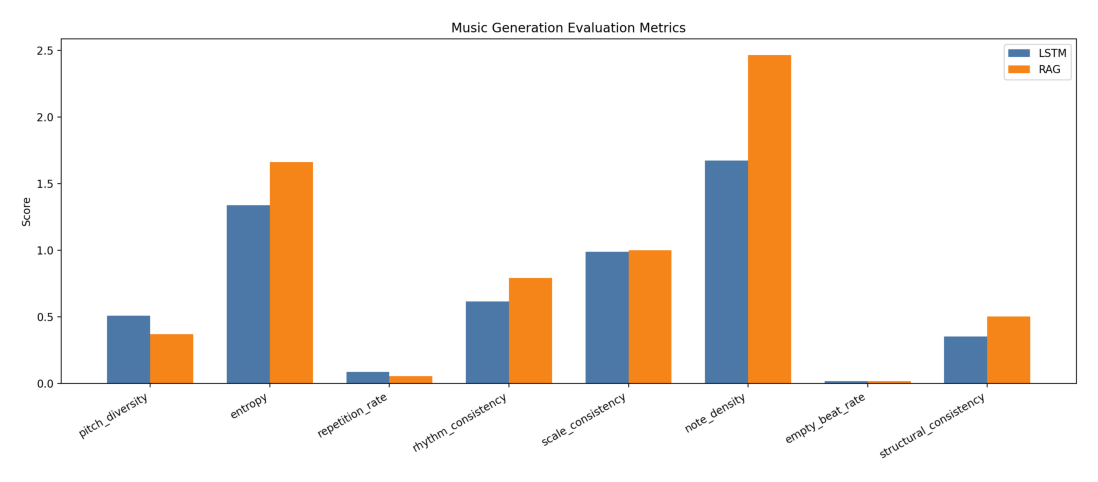

In [75]:
%matplotlib inline
import matplotlib.pyplot as plt

figure = plt.imread(plot_path)
plt.figure(figsize=(14, 6))
plt.imshow(figure)
plt.axis('off')
plt.show()

analysis_text = generate_results_analysis(results)


## Subjective Evaluation (MOS)

Expected CSV schema:

```text
participant_id,sample_id,model,dimension,rating
1,1,lstm,naturalness,3
1,1,lstm,overall,3
1,2,lstm,naturalness,3
1,2,lstm,overall,3
1,3,lstm,naturalness,3
1,3,lstm,overall,3
1,4,lstm,naturalness,3
1,4,lstm,overall,3
1,5,rag,naturalness,4
1,5,rag,overall,4
1,6,rag,naturalness,4
1,6,rag,overall,4
1,7,rag,naturalness,4
1,7,rag,overall,4
1,8,rag,naturalness,4
1,8,rag,overall,4
```

This module computes MOS, 95% confidence intervals, an independent two-sample t-test, a report-ready console table, and a bar chart with error bars.

In [76]:
mos_csv_path = ROOT / 'mos_ratings.csv'
mos_results_path = ROOT / 'mos_results.json'
mos_plot_path = ROOT / 'mos_comparison.png'

if mos_csv_path.exists():
    mos_results = analyze_mos(mos_csv_path, mos_results_path, mos_plot_path)
    print_results(mos_results)
    mos_results
else:
    print(f'MOS CSV not found: {mos_csv_path}')
    print('Create the file with the required schema, then rerun this cell.')

Model     Naturalness (MOS±CI)        Overall (MOS±CI)            
--------------------------------------------------------------------
LSTM      3.01 ± 0.14                 3.08 ± 0.13                 
RAG       3.99 ± 0.13                 4.25 ± 0.09                 
--------------------------------------------------------------------
naturalness p-value: 0.0000 (significant)
overall p-value: 0.0000 (significant)


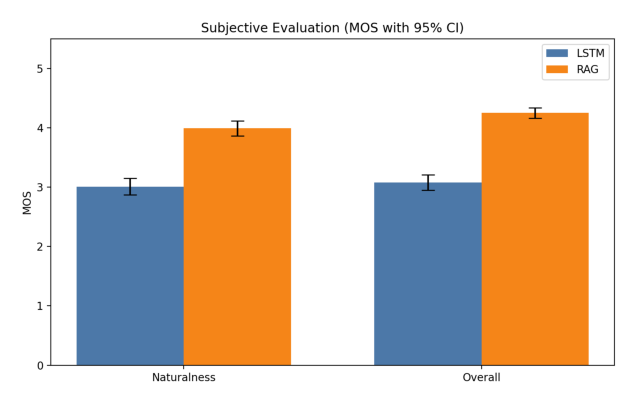

In [77]:
if mos_plot_path.exists():
    mos_figure = plt.imread(mos_plot_path)
    plt.figure(figsize=(8, 5))
    plt.imshow(mos_figure)
    plt.axis('off')
    plt.show()
else:
    print('MOS plot not available yet.')